# 🛒 Retail Sales & Customer Insights Analysis
## ✍️ Author: Kgotlello Leshike

### 📊 Project Overview
This notebook explores a **retail sales and customer demographics dataset**, simulating a dynamic retail environment.  
I used **SQL queries in SQLite via pandas** to extract actionable insights
### 🔍 Key Features & Insights
- 💰 **Revenue Analysis:** Identify which product categories contribute the most to revenue and units sold.  
- 🗓️ **Time-Based Trends:** Examine **monthly and quarterly sales trends**, uncovering seasonal spikes and top-performing categories.  
- 👑 **Top Customers & Frequent Buyers:** Detect high-spending and highly active customers driving sales.  
- 🚻 **Customer Demographics:** Analyze purchasing behavior by **age and gender**, and link it to product preferences.  
- 🏆 **High-Value Orders:** Highlight unusual or large transactions (top 5% orders).  
- 🔢 **Quantity Insights:** Understand which products are purchased in higher volumes.  
- 📈 **Seasonal Patterns:** Track product category performance **by month and quarter**, revealing trends across seasons.  

### 🎯 Objective
Transform raw retail data into **strategic business insights**, supporting decisions in:

- Sales & revenue optimization  
- Customer segmentation & marketing strategy  
- Inventory and product category planning  
- Identification of seasonal opportunities  

# 📥 Load Retail Sales Dataset

**Purpose:** Download, load, and inspect the Retail Sales dataset.

**Key Points:**
- Loads dataset from KaggleHub into pandas.
- Parse the `Date` column as datetime.
- Quick inspection of first 5 rows, column info, and missing values.
- Confirms dataset is clean and ready for analysis.

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset from KaggleHub
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")
csv_file = path + "/retail_sales_dataset.csv"

# Load CSV into pandas
df = pd.read_csv(csv_file, parse_dates=['Date'])

# Quick check
print("First 5 rows:")
display(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
First 5 rows:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB
None

Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total A

# 📝 Findings & Summary

- Dataset contains **1000 transactions** with complete data.
- Columns: `Transaction ID`, `Date`, `Customer ID`, `Gender`, `Age`, `Product Category`, `Quantity`, `Price per Unit`, `Total Amount`.
- **Data types** are appropriate (`Date` is datetime, numeric columns are int64).
- **No missing values** detected.
- Initial inspection shows variability in transaction amounts, product categories, and customer demographics.

# 🗄️ Connect to SQLite and Load Dataset

**Purpose:** Set up an in-memory SQLite database and load the dataset for SQL querying.

**Key Points:**
- Uses `sqlite3` to create an **in-memory database**.
- Loads the pandas DataFrame into a table called `retail_sales`.
- Prepares the dataset for **SQL queries**, which will be used to generate business insights.

In [3]:
import sqlite3

# Connect to SQLite (in-memory database)
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite table
df.to_sql("retail_sales", conn, index=False, if_exists="replace")

print("Table 'retail_sales' created in SQLite. Ready for SQL queries!")

Table 'retail_sales' created in SQLite. Ready for SQL queries!


# 💰 Total Revenue & Units Sold per Product Category

**Purpose:** Summarize revenue and sales volume by product category to identify top-performing categories.

**Key Points:**
- SQL aggregates `Total Amount` and `Quantity` per `Product Category`.
- Grouped by category and sorted by total revenue decreasing order.
- Helps answer: **Which product categories generate the most revenue and units sold?**
- Important for **inventory planning and marketing focus**.

In [4]:
query = """
SELECT
    "Product Category",
    SUM("Total Amount") AS Total_Revenue,
    SUM("Quantity") AS Total_Units_Sold
FROM retail_sales
GROUP BY "Product Category"
ORDER BY Total_Revenue DESC;
"""
total_revenue_by_product_category = pd.read_sql_query(query, conn)
total_revenue_by_product_category

,Product Category,Total_Revenue,Total_Units_Sold
0,Electronics,156905,849
1,Clothing,155580,894
2,Beauty,143515,771


/tmp/ipykernel_895/218720486.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


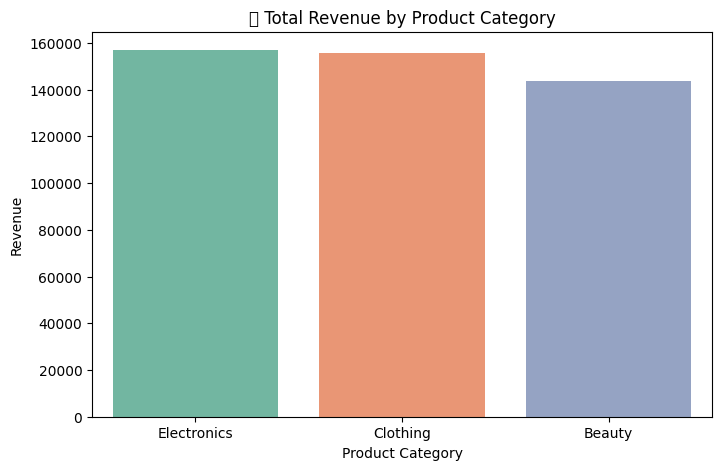

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=total_revenue_by_product_category,
    x="Product Category",
    y="Total_Revenue",
    palette="Set2"
)
plt.title("💰 Total Revenue by Product Category")
plt.ylabel("Revenue")
plt.xlabel("Product Category")
plt.show()

# 📝 Findings & Summary

- Revenue and units sold do **not always align** (e.g., Clothing has more units sold than Electronics but slightly lower revenue).
- Provides insights for:
  - **Sales strategy:** Focus on high-revenue categories.
  - **Stock management:** Ensure categories are sufficiently stocked according to demand [demand management].
  - **Promotional planning:** Identify categories that might need marketing support.

# 📅 Monthly Revenue & Units Sold

**Purpose:** Track sales performance over time to detect trends and seasonality.

**Key Points:**
- Helps answer: **How do revenue and units sold fluctuate month-to-month?**
- Important for **trend analysis, forecasting, and inventory planning**.

In [6]:
query = """
SELECT
    STRFTIME('%Y-%m', Date) AS Month,
    SUM("Total Amount") AS Revenue,
    SUM(Quantity) AS Units_Sold
FROM retail_sales
GROUP BY Month
ORDER BY Month;
"""
monthly_revenue_and_units_sold = pd.read_sql_query(query, conn)
monthly_revenue_and_units_sold

,Month,Revenue,Units_Sold
0,2023-01,35450,195
1,2023-02,44060,214
2,2023-03,28990,194
3,2023-04,33870,214
4,2023-05,53150,259
5,2023-06,36715,197
6,2023-07,35465,176
7,2023-08,36960,227
8,2023-09,23620,170
9,2023-10,46580,252


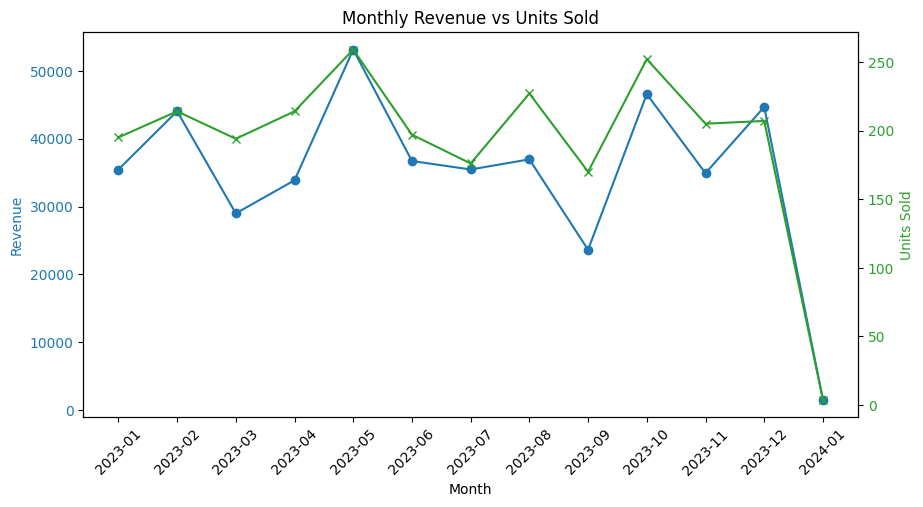

In [8]:
fig, ax1 = plt.subplots(figsize=(10,5))

color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue', color=color)
ax1.plot(
    monthly_revenue_and_units_sold['Month'],
    monthly_revenue_and_units_sold['Revenue'],
    color=color, marker='o'
)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()  # secondary axis
color = 'tab:green'
ax2.set_ylabel('Units Sold', color=color)
ax2.plot(
    monthly_revenue_and_units_sold['Month'],
    monthly_revenue_and_units_sold['Units_Sold'],
    color=color, marker='x'
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Monthly Revenue vs Units Sold")
plt.show()

# 📝 Findings & Summary

- Peak revenue and units sold occur in **May, October, and December**, indicating potential seasonal demand spikes.
- Some months (e.g., January 2024) have extremely low sales—likely due to **incomplete dataset or low transaction volume**.
- Insights for:
  - **Marketing campaigns:** Plan promotions around high-demand months.
  - **Inventory management:** Adjust stock levels for seasonality.
  - **Sales forecasting:** Use trends to anticipate future performance.

# 👑 Top 10 Customers by Total Spending

**Purpose:** Identify the customers contributing most to revenue.

**Key Points:**
- Sums `Total Amount` per `Customer ID` and counts their transactions.
- Orders by total spending in descending order and limits to top 10.
- Helps answer: **Who are the highest-value customers?**
- Useful for **targeted marketing or even loyalty programs**.

In [9]:
query = """
SELECT
    "Customer ID",
    SUM("Total Amount") AS Total_Spent,
    COUNT(*) AS Transactions
FROM retail_sales
GROUP BY "Customer ID"
ORDER BY Total_Spent DESC
LIMIT 10;
"""
top_10_customers_by_spending = pd.read_sql_query(query, conn)
top_10_customers_by_spending

,Customer ID,Total_Spent,Transactions
0,CUST970,2000,1
1,CUST946,2000,1
2,CUST927,2000,1
3,CUST875,2000,1
4,CUST832,2000,1
5,CUST808,2000,1
6,CUST789,2000,1
7,CUST773,2000,1
8,CUST743,2000,1
9,CUST742,2000,1


# 📝 Findings & Summary

- Each of the top 10 customers spent **exactly 2000** in a single transaction.
- No customer shows multiple transactions in this top group. Need to rewrite this code?? maybe change it to something else

# 👩‍🦰👨 Average Order Value and Quantity by Gender

**Purpose:** Compare purchasing behavior between male and female customers.

**Key Points:**
- Helps answer: **Do males and females buy differently?**
- Useful for **marketing strategies, product targeting, and inventory planning**.

In [11]:
query = """
SELECT
    Gender,
    AVG("Total Amount") AS Avg_Order_Value,
    AVG(Quantity) AS Avg_Quantity
FROM retail_sales
GROUP BY Gender;
"""
average_order_value_by_gender = pd.read_sql_query(query, conn)
average_order_value_by_gender

,Gender,Avg_Order_Value,Avg_Quantity
0,Female,456.549020,2.545098
1,Male,455.428571,2.481633


/tmp/ipykernel_895/513855612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_895/513855612.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


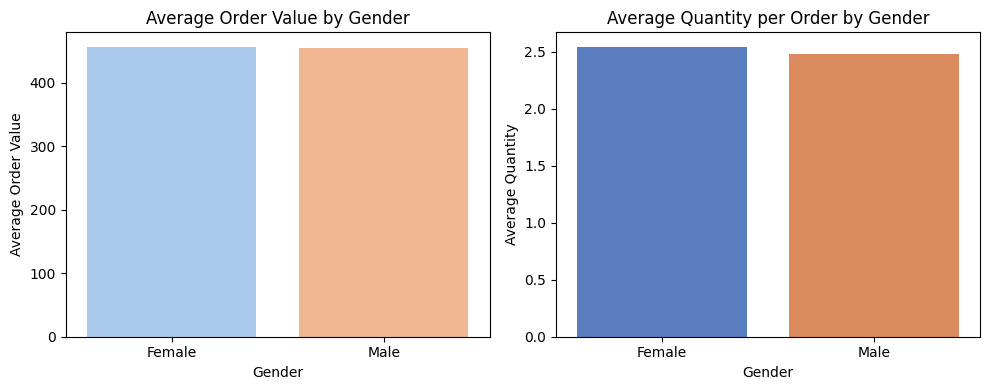

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.barplot(
    data=average_order_value_by_gender,
    x="Gender",
    y="Avg_Order_Value",
    ax=ax[0],
    palette="pastel"
)
ax[0].set_title("Average Order Value by Gender")
ax[0].set_ylabel("Average Order Value")
ax[0].set_xlabel("Gender")

sns.barplot(
    data=average_order_value_by_gender,
    x="Gender",
    y="Avg_Quantity",
    ax=ax[1],
    palette="muted"
)
ax[1].set_title("Average Quantity per Order by Gender")
ax[1].set_ylabel("Average Quantity")
ax[1].set_xlabel("Gender")

plt.tight_layout()
plt.show()

# 📝 Findings & Summary

- **Female customers** have a slightly higher average order value (≈ 456.55) and average quantity (≈ 2.55) than male customers (≈ 455.43 & 2.48).
- Differences are small, suggesting **similar purchasing patterns across genders**.


# 💸 Top 5% High-Value Orders

**Purpose:** Identify unusually large transactions that contribute significantly to total revenue.

**Key Points:**
- Used `PERCENT_RANK()` to rank orders by `Total Amount`.
- Selected the **top 5% of orders** based on transaction value.
- Helps answer:
  - Which orders are **high-value outliers**?
  - Which customers or product categories generate **biggest sales per transaction**.
- Useful for **targeted marketing, VIP customer identification, and fraud detection**.

In [13]:
query = """
WITH OrderRanks AS (
    SELECT *,
           PERCENT_RANK() OVER (ORDER BY "Total Amount" DESC) AS rank
    FROM retail_sales
)
SELECT *
FROM OrderRanks
WHERE rank <= 0.05
ORDER BY "Total Amount" DESC;
"""
top_5_percent_orders = pd.read_sql_query(query, conn)
top_5_percent_orders

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,rank
0,15,2023-01-16 00:00:00,CUST015,Female,42,Electronics,4,500,2000,0.000000
1,65,2023-12-05 00:00:00,CUST065,Male,51,Electronics,4,500,2000,0.000000
2,72,2023-05-23 00:00:00,CUST072,Female,20,Electronics,4,500,2000,0.000000
3,74,2023-11-22 00:00:00,CUST074,Female,18,Beauty,4,500,2000,0.000000
4,89,2023-10-01 00:00:00,CUST089,Female,55,Electronics,4,500,2000,0.000000
...,...,...,...,...,...,...,...,...,...,...
94,843,2023-05-22 00:00:00,CUST843,Male,21,Beauty,3,500,1500,0.049049
95,859,2023-08-18 00:00:00,CUST859,Female,56,Electronics,3,500,1500,0.049049
96,869,2023-10-25 00:00:00,CUST869,Male,37,Beauty,3,500,1500,0.049049
97,942,2023-03-18 00:00:00,CUST942,Male,51,Clothing,3,500,1500,0.049049


# 📝 Findings & Summary

- Top 5% orders mostly involve **Electronics and high-priced items** (up to 2000 per transaction).  
- Quantity for these orders is often **3–4 items per transaction**.  
- Customers in this range span **all ages and genders**, but Electronics dominates high-value sales.  


# 📦 Average Quantity per Order by Product Category

**Purpose:** Understand the typical number of items purchased per transaction for each product category.

**Key Points:**
- Calculated the **average quantity per order** using `AVG(Quantity)`.
- Groupedd results by **Product Category** to compare categories.
- Highlights:
  - Which products are bought in **larger bundles** vs individually.
  - Helps in **inventory planning** and **promotional strategy**.

In [14]:
query = """
SELECT
    "Product Category",
    AVG(Quantity) AS Avg_Quantity_Per_Order
FROM retail_sales
GROUP BY "Product Category"
ORDER BY Avg_Quantity_Per_Order DESC;
"""
average_quantity_per_product_category = pd.read_sql_query(query, conn)
average_quantity_per_product_category

,Product Category,Avg_Quantity_Per_Order
0,Clothing,2.547009
1,Beauty,2.511401
2,Electronics,2.482456


# 📝 Findings & Summary

- **Clothing** has the highest average quantity per order (~ 2.55 items), followed by **Beauty** and **Electronics** (~2.5 items).  
- Indicates that customers tend to **buy multiple clothing or beauty items at a time**, but Electronics are usually **bought individually or in smaller quantities**.  
- Useful for:
  - **Stock allocation**: Ensure sufficient inventory for high-volume categories.

# 👥 Total Revenue & Unique Customers by Age Group

**Purpose:** Understand revenue contribution and customer distribution across different age segments.

- Helps identify which age groups are the most **valuable** to the business.

In [15]:
query = """
SELECT
    CASE
        WHEN Age BETWEEN 18 AND 25 THEN '18-25'
        WHEN Age BETWEEN 26 AND 35 THEN '26-35'
        WHEN Age BETWEEN 36 AND 45 THEN '36-45'
        WHEN Age BETWEEN 46 AND 55 THEN '46-55'
        WHEN Age BETWEEN 56 AND 65 THEN '56-65'
        ELSE 'Other'
    END AS Age_Group,
    SUM("Total Amount") AS Total_Revenue,
    COUNT(DISTINCT "Customer ID") AS Unique_Customers
FROM retail_sales
GROUP BY Age_Group
ORDER BY Total_Revenue DESC;
"""
revenue_and_unique_customers_by_age_group = pd.read_sql_query(query, conn)
revenue_and_unique_customers_by_age_group

,Age_Group,Total_Revenue,Unique_Customers
0,46-55,100690,229
1,26-35,98480,205
2,36-45,91870,202
3,18-25,84550,169
4,56-65,80410,195


/tmp/ipykernel_895/1961912699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


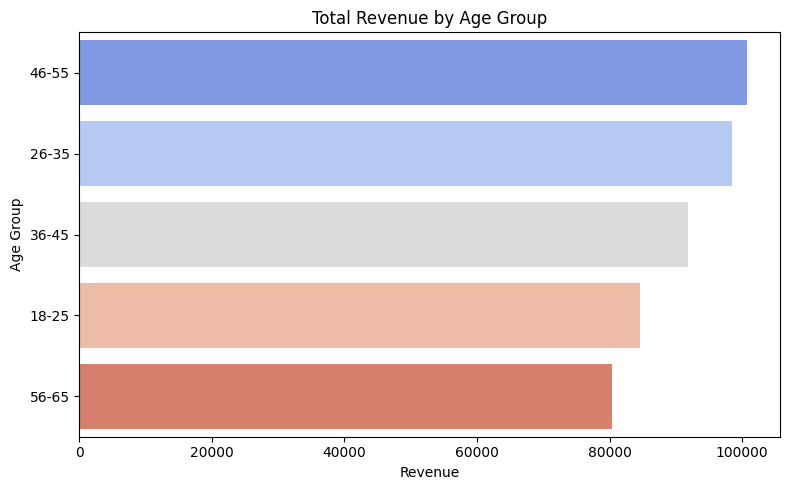

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=revenue_and_unique_customers_by_age_group,
    x="Total_Revenue",
    y="Age_Group",
    palette="coolwarm"
)
plt.title("Total Revenue by Age Group")
plt.xlabel("Revenue")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

# 📝 Findings & Summary

- **46-55 years** contribute the **highest revenue** (~100,690) with **229 unique customers**.  
- **26-35** and **36-45** also drive significant revenue and have a large customer base.  
- **18-25** age group has fewer customers but still a healthy revenue contribution (~84,550).  
- Insights:
  - Focus marketing campaigns on **46-55 and 26-35 age groups** for high ROI.
  - Younger customers could be targeted for **growth and retention strategies**.

# 🏷️ Revenue & Units Sold by Product Category and Gender

**Purpose:** Analyze how sales and order volumes differ across product categories and customer gender.

**Key Points:**
- Calculates:
  - **Revenue** per category-gender combination (`SUM("Total Amount")`)
  - **Units Sold** per category-gender combination (`SUM(Quantity)`)
- Helps understand **gender-specific preferences** and which products generate the most sales for each gender.

In [17]:
query = """
SELECT
    "Product Category",
    Gender,
    SUM("Total Amount") AS Revenue,
    SUM(Quantity) AS Units_Sold
FROM retail_sales
GROUP BY "Product Category", Gender
ORDER BY Revenue DESC;
"""
revenue_and_units_by_category_and_gender = pd.read_sql_query(query, conn)
revenue_and_units_by_category_and_gender

,Product Category,Gender,Revenue,Units_Sold
0,Clothing,Female,81275,441
1,Electronics,Male,80170,410
2,Electronics,Female,76735,439
3,Beauty,Female,74830,418
4,Clothing,Male,74305,453
5,Beauty,Male,68685,353


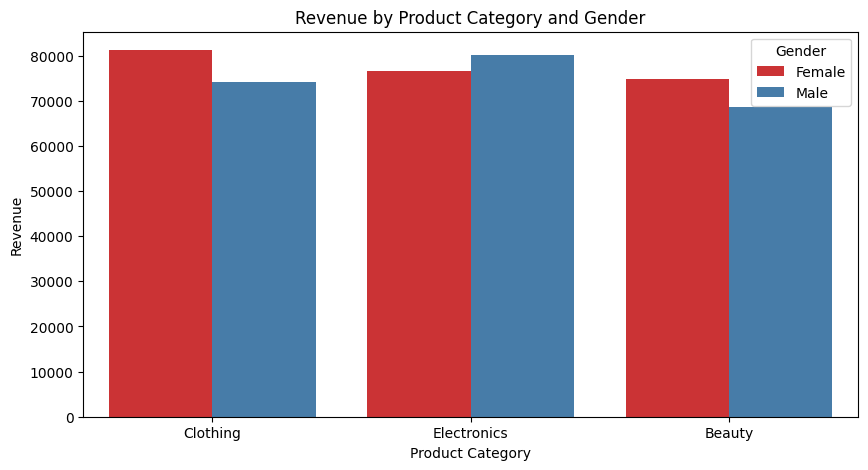

In [19]:
# Revenue by Product Category & Gender
plt.figure(figsize=(10,5))
sns.barplot(
    data=revenue_and_units_by_category_and_gender,
    x="Product Category",
    y="Revenue",
    hue="Gender",
    palette="Set1"
)
plt.title("Revenue by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

# 📝 Findings & Summary

- **Clothing (Female)** is the **top revenue driver** (~81,275) with 441 units sold.  
- **Electronics (Male)** follows closely (~80,170 revenue).  
- Female customers spend more on **Beauty and Clothing**, while males dominate **Electronics**.  
- Insights:
  - Tailor **marketing campaigns and promotions by gender**.  


# 📅 Top Product Category by Revenue per Month

**Purpose:** Identify which product category generated the **highest revenue each month**.

**Key Points:**
- **CTE (Common Table Expression)** to calculate monthly revenue per category.
- For each month, selects the **category with the maximum revenue**.
- Helps detect **seasonal trends and peak performers**.
- Useful for **inventory planning and demand forcasting**.

In [20]:
query = """
WITH MonthlyRevenue AS (
    SELECT
        STRFTIME('%Y-%m', Date) AS Month,
        "Product Category",
        SUM("Total Amount") AS Revenue
    FROM retail_sales
    GROUP BY Month, "Product Category"
)
SELECT Month, "Product Category", Revenue
FROM MonthlyRevenue AS mr1
WHERE Revenue IN (
    SELECT MAX(Revenue)
    FROM MonthlyRevenue AS mr2
    WHERE mr2.Month = mr1.Month
)
ORDER BY Month;
"""
top_category_by_revenue_per_month = pd.read_sql_query(query, conn)
top_category_by_revenue_per_month

,Month,Product Category,Revenue
0,2023-01,Clothing,13125
1,2023-02,Electronics,15465
2,2023-03,Clothing,15065
3,2023-04,Clothing,13940
4,2023-05,Electronics,23245
5,2023-06,Electronics,15550
6,2023-07,Beauty,16090
7,2023-08,Electronics,14715
8,2023-09,Clothing,9975
9,2023-10,Electronics,17910


# 📝 Findings & Summary

- **Electronics** and **Clothing** dominate most months, with **Beauty** occasionally leading (e.g., July 2023, Jan 2024).  
- Revenue spikes in **May and December** indicate seasonal trends, likely tied to promotions or holidays.  
- Insights:
  - Plan **stocking and marketing campaigns** around peak months for each category.
  - Use trends to **forecast demand** and reduce inventory shortages.
- Note: January 2024 shows low total revenue (1500) – due to limited data for that month - the dataset ends there.

# 👥 Top Frequent Buyers

**Purpose:** Identify customers with the **highest number of transactions**.  

**Key Points:**
- Orders are sorted by **number of transactions** in descending order.
- Shows who the **most engaged customers** are, useful for:
  - Targeted marketing campaigns
  - Loyalty programs
  - Reward initiatives
- Helps detect **high-value repeat customers** versus large one-time spenders.

In [21]:
query = """
SELECT "Customer ID", COUNT(*) AS Num_Transactions, SUM("Total Amount") AS Total_Spent
FROM retail_sales
GROUP BY "Customer ID"
ORDER BY Num_Transactions DESC
LIMIT 10;
"""

top_frequent_buyers = pd.read_sql_query(query, conn)
top_frequent_buyers

,Customer ID,Num_Transactions,Total_Spent
0,CUST999,1,150
1,CUST998,1,100
2,CUST997,1,90
3,CUST996,1,50
4,CUST995,1,30
5,CUST994,1,1000
6,CUST993,1,150
7,CUST992,1,60
8,CUST991,1,100
9,CUST990,1,1000


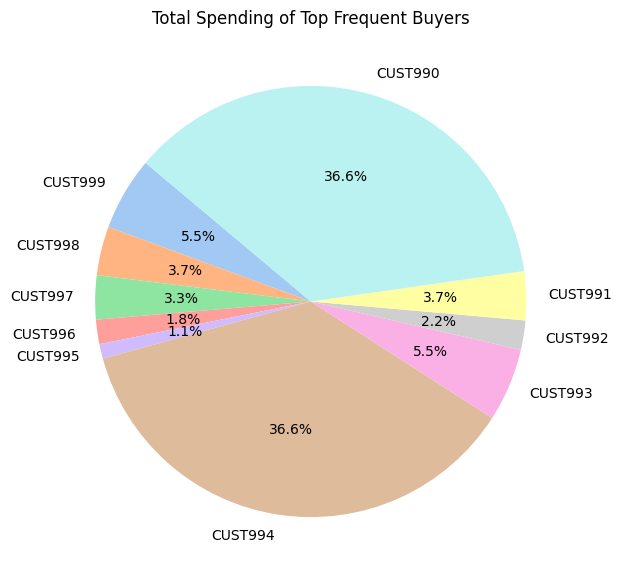

In [22]:
plt.figure(figsize=(7,7))
plt.pie(
    top_frequent_buyers["Total_Spent"],
    labels=top_frequent_buyers["Customer ID"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")[0:10]
)
plt.title("Total Spending of Top Frequent Buyers")
plt.show()

# 📝 Findings & Summary

- Each of the top 10 customers has **1 transaction**, indicating **low repeat purchase frequency** in this dataset.  
- Some customers (e.g., CUST994, CUST990) spent **significantly more than others**, showing that **high spenders are not necessarily frequent buyers**.  


# 📆 Quarterly Revenue by Product Category

**Purpose:** Analyze **seasonal trends** in product category revenue.  

**Key Points:**
- Calculated **total revenue per product category** for each quarter.
- Groups sales by **year and quarter**, then orders by revenue descending.
- Helps identify:
  - Which products perform best each quarter
  - Seasonal spikes and slow periods
  - Opportunities for **inventory planning** and **promotions**
- Essential for understanding **quarterly performance patterns** and guiding business strategy.

In [27]:
query = """
-- Quarterly revenue per product category
SELECT
    STRFTIME('%Y', Date) || '-Q' || ((CAST(STRFTIME('%m', Date) AS INTEGER)-1)/3 + 1) AS Quarter,
    "Product Category",
    SUM("Total Amount") AS Revenue
FROM retail_sales
GROUP BY Quarter, "Product Category"
ORDER BY Quarter, Revenue DESC;
"""

quarterly_revenue_by_product_category = pd.read_sql_query(query, conn)
quarterly_revenue_by_product_category.head(20)

,Quarter,Product Category,Revenue
0,2023-Q1,Clothing,42750
1,2023-Q1,Beauty,37010
2,2023-Q1,Electronics,28740
3,2023-Q2,Electronics,46820
4,2023-Q2,Clothing,41565
5,2023-Q2,Beauty,35350
6,2023-Q3,Electronics,33165
7,2023-Q3,Beauty,32200
8,2023-Q3,Clothing,30680
9,2023-Q4,Electronics,48150


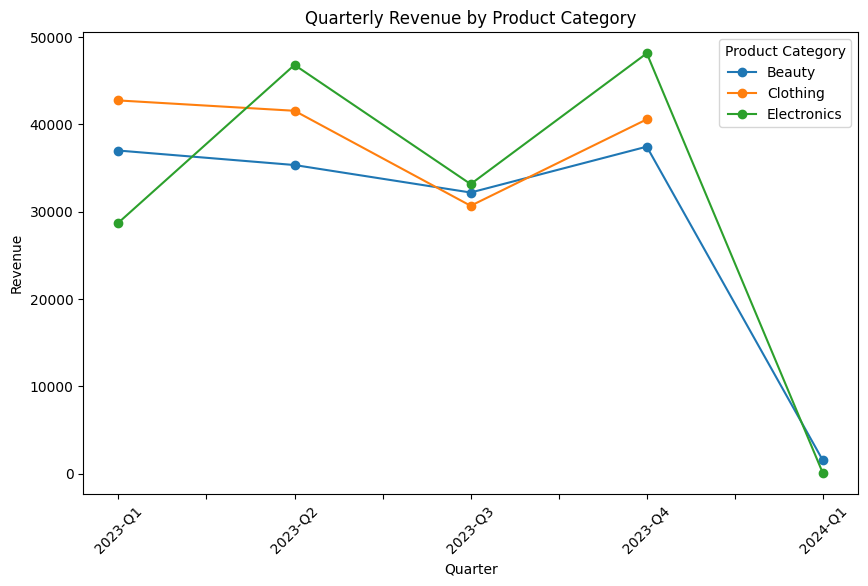

In [30]:
pivot_quarterly = quarterly_revenue_by_product_category.pivot(        #Im sure theres something wrong here. edit before release!!
    index="Quarter",
    columns="Product Category",
    values="Revenue"
)

pivot_quarterly.plot(kind="line", figsize=(10,6), marker='o')
plt.title("Quarterly Revenue by Product Category")
plt.ylabel("Revenue")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.show()

# 📝 Findings & Summary

- **Q1 2023:** Clothing leads revenue, followed by Beauty and Electronics.  
- **Q2 2023:** Electronics overtakes Clothing, likely due to seasonal demand.  
- **Q3 2023:** Electronics still strong, but Beauty also performs well.  
- **Q4 2023:** Electronics peaks again, consistent with **holiday season trends**.  


# 📊 Business Insights & Recommendations

Based on the Retail Sales and Customer Demographics dataset, the analysis reveals several actionable insights:

## 1️⃣ Revenue & Product Performance
- **Clothing** dominates in Q1 and certain months; **Electronics** peaks in Q2 and Q4, aligning with seasonal demand (e.g., holidays, promotions).
- **Beauty** performs consistently but slightly below Clothing and Electronics.

## 2️⃣ Customer Behavior
- Top spending customers often make **single high-value purchases**, suggesting targeted loyalty or repeat-purchase strategies could increase lifetime value.
- Gender-based analysis shows **slightly higher average order value for females** (≈456 vs 455) but similar quantities purchased, indicating we have the same buying behavior.

## 3️⃣ Demographics Insights
- **Age groups 46-55 and 26-35** contribute the most revenue, representing key target demographics.
- Younger customers (18-25) and older customers (56-65) spend less individually but may provide volume growth potential.
- If we target the younger generation and build a relationship with them, in a couple of years they will fall into the 46 - 55 years age group which means we will have retained / kept customers till they reach the ages where they contribute the most revenue.

## 4️⃣ Orders & Quantity Patterns
- **Top 5% high-value orders** mostly involve Electronics and occasional Beauty purchases.
- Average quantities per order are similar across categories (~2.5 items/order), suggesting customers prefer **moderate basket sizes**.

## ✅ Recommendations
- Prioritize **stocking and marketing Electronics and Clothing** during peak quarters.
- Develop **targeted campaigns for 26-55 age group**.
- Explore **loyalty programs** for high-value customers to encourage repeat purchases.
- Monitor low-performing quarters or categories for potential **bundling or promotional strategies**.
- Demand forecasting should be done on a quartlely basis so we are more in control of the dips and surges of the different products.
- We need to find out why we are not appealing to the younger generation.

A dashboard is attached to this GitHub for better visualization.

In [31]:
exports = {
    "total_revenue_by_product_category.csv": total_revenue_by_product_category,
    "monthly_revenue_and_units_sold.csv": monthly_revenue_and_units_sold,
    "top_10_customers_by_spending.csv": top_10_customers_by_spending,
    "average_order_value_by_gender.csv": average_order_value_by_gender,
    "top_5_percent_orders.csv": top_5_percent_orders,
    "average_quantity_per_product_category.csv": average_quantity_per_product_category,
    "revenue_and_unique_customers_by_age_group.csv": revenue_and_unique_customers_by_age_group,
    "revenue_and_units_by_category_and_gender.csv": revenue_and_units_by_category_and_gender,
    "top_category_by_revenue_per_month.csv": top_category_by_revenue_per_month,
    "top_frequent_buyers.csv": top_frequent_buyers,
    "quarterly_revenue_by_product_category.csv": quarterly_revenue_by_product_category
}

for filename, df in exports.items():
    df.to_csv(f"/content/{filename}", index=False)
    print(f"Saved {filename}")

Saved total_revenue_by_product_category.csv
Saved monthly_revenue_and_units_sold.csv
Saved top_10_customers_by_spending.csv
Saved average_order_value_by_gender.csv
Saved top_5_percent_orders.csv
Saved average_quantity_per_product_category.csv
Saved revenue_and_unique_customers_by_age_group.csv
Saved revenue_and_units_by_category_and_gender.csv
Saved top_category_by_revenue_per_month.csv
Saved top_frequent_buyers.csv
Saved quarterly_revenue_by_product_category.csv
